# Free-Lunch — a quantitative teardown 🔬
### The self-financing ledger · the 2.77× leverage · the excess-of-cash race · the financing sweep · the duration confound

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Free lunch?: Busted](https://img.shields.io/badge/Free_lunch%3F-Busted-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). We build BAB on a tradable ETF cross-section, finance it explicitly, and check what its long leg really is.

> ⚠️ **Not investment advice.** 13 ETFs + SPY + ^IRX, daily, 2000–2026 (Yahoo). ETFs keep it survivorship-free at the cost of coarser beta dispersion. Sources in [`docs/references.md`](../docs/references.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../../.."))  # repo root (quantlab/)
sys.path.insert(0, os.path.abspath(".."))        # study package (free_lunch/)
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 5.5); plt.rcParams["axes.grid"] = True
import numpy as np, pandas as pd
from free_lunch import data, strategy as st
from quantlab import repro
assets, market, rf_ann = data.fetch_etf_panel()  # cache-first; built by examples/verify.py --fetch
cut = pd.Timestamp(repro.DEFAULT_AS_OF)          # pin: complete months strictly before the desk as-of
assets, market, rf_ann = assets[assets.index < cut], market[market.index < cut], rf_ann[rf_ann.index < cut]
rf_m = data.monthly_rf(rf_ann)
gross, lev = st.bab_returns(assets, market, rf_m, return_leverage=True)
mkt = st.market_monthly(market).loc[gross.index]
rf = rf_m.reindex(gross.index).fillna(0.0)       # the cash hurdle every Sharpe is measured against


## Verdict, up front

| Axis | Stamp | Why |
|---|---|---|
| Signal | **Weak** | gross excess Sharpe 0.32 < market 0.48 |
| Tradability | **Mirage** | 2.77× leverage; net Sharpe 0.32→0.23→0.09, negative past ~3.5% spread |
| Free lunch? | **Busted** | the premium is the leverage rent; the 'decay' is the bond bull ending |

> 💡 *In plain words:* the headline lives in a free-funding assumption, and the glory years lived in TLT.

## 1 · The claim, steelmanned

- **H₁:** the beta-neutral low-minus-high book earns a positive gross premium (excess of cash, the F&P construction).
- **H₂ (the pitch):** it beats the market risk-adjusted after the financing its leverage requires.
- **H₃:** the edge is a stable intra-equity anomaly, not an artifact of what's in the low-beta bucket.

## 2 · So what? — what rides on each

If H₂ holds it's a low-risk market-beater. If only H₁ holds, the premium is real but captured by the lender, not you. If H₃ fails, even the gross premium is a different trade wearing BAB's label.

## 3 · How we'd know — the protocol

Trailing betas → median split → lever each leg to beta 1 (record the long-leg leverage) → **self-financing ledger**: borrowed slice at rf + spread, short rebate at rf − fee, capital at rf, every dollar once → excess-of-cash race vs SPY → financing-spread sweep → decompose the long leg (TLT correlation; intra-equity-only rebuild).

## 4 · The teardown

### 4.1 The construction, its leverage, and the fair race

In [2]:
print(f'avg long-leg leverage = {lev:.2f}x  (low-beta leg β≈{1/lev:.2f} levered to 1); avg T-bill {rf.mean()*12:.1%}/yr')
display(pd.DataFrame({'BAB gross (self-financed)':st.summary(gross+rf,rf=rf),'SPY':st.summary(mkt,rf=rf)}).T[['cagr','sharpe','vol_ann','max_drawdown']].round(3))

avg long-leg leverage = 2.77x  (low-beta leg β≈0.36 levered to 1); avg T-bill 1.9%/yr


,cagr,sharpe,vol_ann,max_drawdown
BAB gross (self-financed),0.066,0.318,0.216,-0.475
SPY,0.083,0.476,0.152,-0.508


> 💡 *In plain words:* both lines are measured over the same T-bill (the BAB row is the funded book, rf + long-short P&L, so the CAGRs are comparable too). Even at zero frictions BAB's Sharpe trails the market's. **H₁ holds only weakly** — there's a tilt, but it doesn't clear the bar. Note what changed vs the naive comparison: a raw long-short return pockets free funding on its net-long notional (≈ rf × (w_L − w_H) ≈ 3.6%/yr here); the F&P excess construction strips that subsidy.

### 4.2 The financing sweep — where the residual edge goes

In [3]:
spreads=np.linspace(0,0.04,9)
tbl=pd.DataFrame({'spread %':spreads*100,
  'BAB net Sharpe':[st.summary(st.bab_returns(assets,market,rf_m,financing_spread_ann=s,borrow_fee_ann=s/4))['sharpe'] for s in spreads]})
display(tbl.round(3).set_index('spread %'))
print('market Sharpe (excess of T-bill) for reference:', round(st.summary(mkt,rf=rf)['sharpe'],2))

,BAB net Sharpe
spread %,
0.0,0.318
0.5,0.272
1.0,0.226
1.5,0.180
2.0,0.134
2.5,0.088
3.0,0.042
3.5,-0.004
4.0,-0.050


market Sharpe (excess of T-bill) for reference: 0.48


> 💡 *In plain words:* a cheap institutional spread (1%) keeps Sharpe 0.23; a retail margin markup (~2.5%, the Study 30 central case) keeps 0.09; past ~3.5% the book loses money. **H₂ rejected** — the leverage rent is the premium.

### 4.3 What the long leg actually is — the duration confound

corr(BAB gross, TLT) = +0.55   corr(BAB gross, SPY) = +0.14
intra-equity book (drop TLT/IEF/GLD): gross Sharpe 0.21, leverage 1.47x


,full book,intra-equity
2000-2012,0.56,0.23
2013-on,0.12,0.20


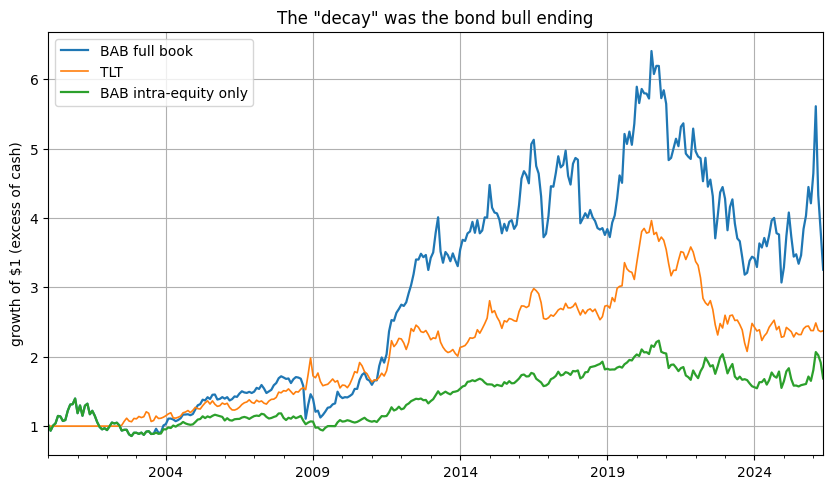

In [4]:
tlt=(1+assets['TLT']).resample('ME').prod()-1
eq_gross,eq_lev=st.bab_returns(assets[data.EQUITY_ONLY],market,rf_m,return_leverage=True)
print(f'corr(BAB gross, TLT) = {gross.corr(tlt.loc[gross.index]):+.2f}   corr(BAB gross, SPY) = {gross.corr(mkt):+.2f}')
print(f'intra-equity book (drop TLT/IEF/GLD): gross Sharpe {st.summary(eq_gross)["sharpe"]:.2f}, leverage {eq_lev:.2f}x')
rows={}
for lab,lo,hi in [('2000-2012',None,'2012'),('2013-on','2013',None)]:
    rows[lab]={'full book':st.summary(gross.loc[lo:hi])['sharpe'],'intra-equity':st.summary(eq_gross.loc[lo:hi])['sharpe']}
display(pd.DataFrame(rows).T.round(2))
ax=((1+gross).cumprod()).plot(label='BAB full book',lw=1.6)
(1+tlt.loc[gross.index]).cumprod().plot(ax=ax,label='TLT',lw=1.2)
(1+eq_gross).cumprod().plot(ax=ax,label='BAB intra-equity only',lw=1.6)
ax.set_title('The "decay" was the bond bull ending'); ax.set_ylabel('growth of $1 (excess of cash)'); ax.legend(); plt.show()

> 💡 *In plain words:* on a cross-asset panel the 'low-beta half' is mostly **Treasuries and gold**, so the levered long leg is half a duration trade — gross book corr +0.55 with TLT. The full book's apparent decay (Sharpe 0.56 → 0.12 around 2013) is the bond bull ending, capped by 2022; the intra-equity rebuild never had it (0.23 → 0.20, flat and small). F&P sort *within* an asset class for exactly this reason. **H₃ rejected** — the early glory was a different trade.

## 5 · The verdict

H₁ weak, H₂ and H₃ rejected → Signal `WEAK`, Tradability `MIRAGE`, free lunch `BUSTED`.

## 6 · Could you trade it?

Only with permanent ~1.8× borrow at the T-bill flat — the very thing the anomaly says constrained investors *lack*. Price your own borrow honestly and there is no edge; price your long leg honestly and half of it was TLT.

## 7 · Going further

Forks: (a) a single-stock universe for genuine intra-equity beta dispersion (more headroom gross, same financing kill); (b) the international BAB variant; (c) a borrow spread that widens exactly when vol spikes — financing is procyclical. Backlog: [`docs/pwb_strategies_inventory.md`](../../../docs/pwb_strategies_inventory.md). Mechanism twin: [Study 30 House-Edge](../../30-house-edge/).